In [1]:
import precice
import deepxde as dde
import numpy as np

# pde setup
from pde_geom import *
from net import *

precice_config = '../precice-config.xml'
solver_process_index = 0
solver_process_size = 1

participant_name = "Feedback"
mesh_name = "Feedback-Mesh"
participant = precice.Participant(participant_name, precice_config, solver_process_index, solver_process_size)

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


---[precice]  This is preCICE version 3.2.0
---[precice]  Revision info: no-info [git failed to run]
---[precice]  Build type: Release (without debug log)
---[precice]  Working directory "/home/dan/Desktop/preCICE/tutorials/volume-coupled-transport/fluid-deepxde"
---[precice]  Configuring preCICE with configuration "../precice-config.xml"
---[precice]  I am participant "Feedback"


In [2]:
# should match openfoam mesh
x_min, x_max = 0.0, domain_length
y_min, y_max = 0.0, domain_width
nx, ny = 60, 40

x_centers = np.linspace(x_min + (x_max - x_min)/(2*nx), x_max - (x_max - x_min)/(2*nx), nx)
y_centers = np.linspace(y_min + (y_max - y_min)/(2*ny), y_max - (y_max - y_min)/(2*ny), ny)

X_grid, Y_grid = np.meshgrid(x_centers, y_centers)
coordinates_precice = np.vstack([X_grid.flatten(), Y_grid.flatten()]).T

vertex_ids_precice = participant.set_mesh_vertices(mesh_name, coordinates_precice)

participant.initialize()
time = 0.0

---[precice]  Setting up primary communication to coupling partner/s
---[precice]  Primary ranks are connected
---[precice]  Setting up preliminary secondary communication to coupling partner/s
---[precice]  Prepare partition for mesh Feedback-Mesh
---[precice]  Receive global mesh Fluid-Mesh
---[precice]  Setting up secondary communication to coupling partner/s
---[precice]  Secondary ranks are connected
---[precice]  Computing "nearest-neighbor" mapping from mesh "Fluid-Mesh" to mesh "Feedback-Mesh" in "read" direction.
---[precice]  Mapping distance min:0 max:0.5 avg: 0.0210417 var: 0.0064635 cnt: 2400
---[precice]  Mapping "Pressure" for t=0 from "Fluid-Mesh" to "Feedback-Mesh" (skipped zero sample)
---[precice]  Mapping "Pressure" for t=0.005 from "Fluid-Mesh" to "Feedback-Mesh"
---[precice]  Mapping "Velocity" for t=0 from "Fluid-Mesh" to "Feedback-Mesh" (skipped zero sample)
---[precice]  Mapping "Velocity" for t=0.005 from "Fluid-Mesh" to "Feedback-Mesh"
---[precice]  iteration

In [3]:
dt_precice = participant.get_max_time_step_size()

In [4]:
V_dataset = []
P_dataset = []
T_dataset = []

In [5]:
velocity_buffer = np.zeros((len(vertex_ids_precice)))

In [6]:
participant.read_data

<bound method Participant.read_data of <cyprecice.Participant object at 0x72bd9117b710>>

In [7]:
while participant.is_coupling_ongoing():
    
    time += dt_precice
        
    Velocity_ground_truth = participant.read_data(mesh_name, "Velocity", vertex_ids_precice, 0)
    Pressure_ground_truth = participant.read_data(mesh_name, "Pressure", vertex_ids_precice, 0)

    print(f"Time: {time:.3f}, dt_precice: {dt_precice:.3f}")

    V_dataset.append(np.copy(Velocity_ground_truth))
    P_dataset.append(np.copy(Pressure_ground_truth))
    T_dataset.append(time)

    participant.advance(dt_precice)

    dt_precice = participant.get_max_time_step_size()
    
participant.finalize()
print("preCICE coupling finished.")

Time: 0.005, dt_precice: 0.005
Time: 0.010, dt_precice: 0.005
---[precice]  Time window completed
Time: 0.015, dt_precice: 0.005
---[precice]  Mapping "Pressure" for t=0.01 from "Fluid-Mesh" to "Feedback-Mesh"
---[precice]  Mapping "Velocity" for t=0.01 from "Fluid-Mesh" to "Feedback-Mesh"
---[precice]  iteration: 1, time-window: 2, time: 0.005 of 10, time-window-size: 0.005, max-time-step-size: 0.005, ongoing: yes, time-window-complete: yes
---[precice]  Time window completed
---[precice]  Mapping "Pressure" for t=0.015 from "Fluid-Mesh" to "Feedback-Mesh"
---[precice]  Mapping "Velocity" for t=0.015 from "Fluid-Mesh" to "Feedback-Mesh"
---[precice]  iteration: 1, time-window: 3, time: 0.01 of 10, time-window-size: 0.005, max-time-step-size: 0.005, ongoing: yes, time-window-complete: yes
Time: 0.020, dt_precice: 0.005
Time: 0.025, dt_precice: 0.005
Time: 0.030, dt_precice: 0.005
Time: 0.035, dt_precice: 0.005
Time: 0.040, dt_precice: 0.005
Time: 0.045, dt_precice: 0.005
Time: 0.050, d

In [48]:
dt_precice = 0.005
T_dataset = np.array(T_dataset)
T_dataset -= T_dataset[0]  # normalize time to start at 0

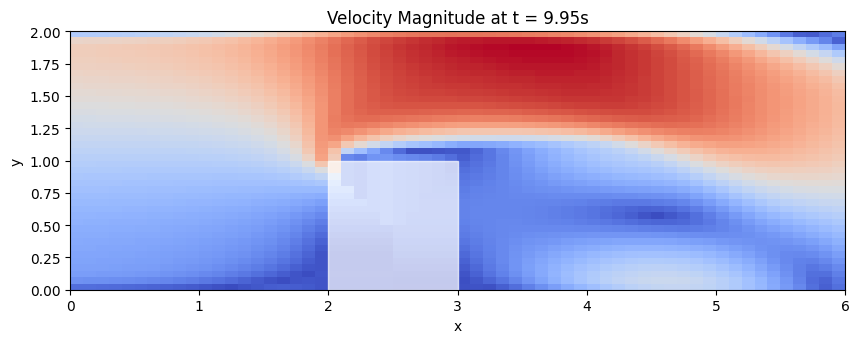

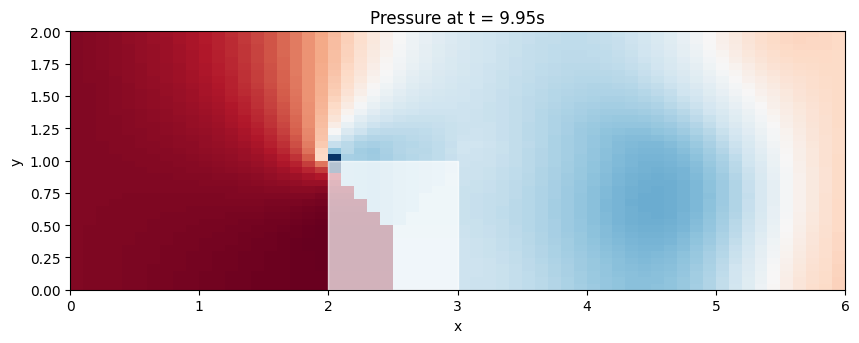

In [49]:
# Pre-process all ground truth data
velocity_magnitudes = [magnitude(v).flatten() for v in V_dataset]
pressure_data = P_dataset

# Skip frames to get 20fps from however many frames you have
total_frames = len(V_dataset)
skip_frames = max(1, total_frames // 200)  # Skip to get ~200 frames max

# Ground truth velocity animation
fig_vel, ax_vel = plt.subplots(figsize=(10, 6))
v_min, v_max = np.min(velocity_magnitudes), np.max(velocity_magnitudes)

def animate_velocity(frame_idx):
    actual_frame = frame_idx * skip_frames
    return update_plot(ax_vel, velocity_magnitudes[actual_frame], T_dataset[actual_frame], 
                      'Velocity Magnitude', vmin=v_min, vmax=v_max)

ani_vel = FuncAnimation(fig_vel, animate_velocity, frames=total_frames//skip_frames, 
                       interval=50, blit=True)
ani_vel.save('velocity_animation.mp4', writer='ffmpeg', fps=20)

# Ground truth pressure animation
fig_press, ax_press = plt.subplots(figsize=(10, 6))
p_min, p_max = np.min(pressure_data), np.max(pressure_data)

def animate_pressure(frame_idx):
    actual_frame = frame_idx * skip_frames
    return update_plot(ax_press, pressure_data[actual_frame], T_dataset[actual_frame],
                      'Pressure', vmin=p_min, vmax=p_max, cmap='RdBu_r')

ani_press = FuncAnimation(fig_press, animate_pressure, frames=total_frames//skip_frames,
                         interval=50, blit=True)
ani_press.save('pressure_animation.mp4', writer='ffmpeg', fps=20)

# Reshape the dataset for training

In [55]:
# X_train (x, y, t) coordinates input
(x, y) = (coordinates_precice[:, 0:1], coordinates_precice[:, 1:2])
# tile the coordinates over time
(x, y) = np.tile(x, (len(T_dataset), 1)), np.tile(y, (len(T_dataset), 1))
t = np.tile(np.array(T_dataset)[:, None], (len(coordinates_precice), 1))

X_train = np.hstack((x, y, t))

print(f"X_train shape: {X_train.shape}")
# y_train (Vx, Vy, P) outputs

all_V = np.vstack(V_dataset)
all_P = np.hstack(P_dataset)
all_P = all_P[:, None] # Reshape P to be a column vector

# Combine them to get the final (u, v, p) output array
Y_train = np.hstack((all_V, all_P))
print(f"Y_train shape: {Y_train.shape}")

# sample part of the data
sample_size = 2**16
indices = np.random.choice(len(X_train), sample_size, replace=False)
X_train = X_train[indices]
Y_train = Y_train[indices]

#save the training data
np.savez('training_data.npz', X_train=X_train, Y_train=Y_train)

X_train shape: (4800000, 3)
Y_train shape: (4800000, 3)


# Define model

In [12]:
unsupervised_loss_terms

In [53]:
import torch
import gc
torch.cuda.empty_cache()
gc.collect()

0

In [54]:
supervised_loss = dde.icbc.PointSetBC(X_train, Y_train)
loss_terms = unsupervised_loss_terms + [supervised_loss]
loss_weights = unsupervised_loss_weights + [10.0]

data = dde.data.TimePDE(
    geom,
    navier_stokes_pde,
    loss_terms,
    num_domain=num_domain_points,
    num_boundary=num_boundary_points,
    num_initial=num_initial_points,
    num_test=num_test_points
)

model = dde.Model(data, net)

lr = 1e-4
model.compile(
    "adam",
    lr=lr,
    loss_weights=loss_weights
)

# # Load  trained model
# model_path = "navier_stokes_channel_obstacle_model-600.pt"

# if not os.path.exists(model_path):
#     print(f"Error: Model file {model_path} not found!")
#     sys.exit(1)
# model.restore(save_path=model_path, verbose=1)

RuntimeError: CUDA error: unspecified launch failure
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
def model_predict(x_mesh, y_mesh, time=0.0):
    n_points_mesh = len(x_mesh.flatten())
    t_values_mesh = np.full(n_points_mesh, time)
    
    # Input to model: (x, y, t)
    points_to_predict = np.vstack((x_mesh.flatten(), y_mesh.flatten(), t_values_mesh)).T
    
    # Model predicts (u, v, p)
    predictions = model.predict(points_to_predict)
    
    u_pred = predictions[:, 0].reshape(x_mesh.shape)
    v_pred = predictions[:, 1].reshape(x_mesh.shape)
    p_pred = predictions[:, 2].reshape(x_mesh.shape)

    Velocity = np.column_stack([u_pred.flatten(), v_pred.flatten()])
    Pressure = p_pred.flatten()
    
    return Velocity, Pressure

Velocity, Pressure = model_predict(X_grid, Y_grid, time=0.0)

Predictions shape: (2400, 3)


In [16]:
# checkpoint_callback = dde.callbacks.ModelCheckpoint(
#     os.path.join(training_output_dir, f"{model_base_name}"),
#     save_better_only=True,
#     period=50
# )

iterations = 25000

losshistory, train_state = model.train(
    iterations=iterations,
    display_every=100
    # callbacks=[checkpoint_callback]
)

Training model...

Step      Train loss                                                                                                                                                          Test loss                                                                                                                                                           Test metric
0         [7.49e-02, 6.84e-02, 3.36e-01, 1.03e+00, 1.35e+00, 1.55e-01, 1.61e+01, 2.45e-02, 4.96e-03, 4.25e+00, 1.50e-02, 5.73e-03, 3.29e+00, 8.65e-01, 4.76e-01, 3.82e+00]    [4.88e-02, 5.54e-02, 2.12e-01, 1.03e+00, 1.35e+00, 1.55e-01, 1.61e+01, 2.45e-02, 4.96e-03, 4.25e+00, 1.50e-02, 5.73e-03, 3.29e+00, 8.65e-01, 4.76e-01, 3.82e+00]    []  
100       [1.20e-02, 1.42e-01, 2.92e-02, 4.15e-01, 5.72e-02, 1.50e-03, 9.07e-01, 7.91e-03, 1.93e-03, 8.71e-02, 2.25e-03, 2.13e-03, 1.18e+00, 1.75e-01, 1.55e-02, 2.30e+00]    [1.04e-02, 1.35e-01, 9.12e-03, 4.15e-01, 5.72e-02, 1.50e-03, 9.07e-01, 7.91e-03, 1.93e-03, 8.71e-02, 2.25e-03, 2.1

In [28]:
model_path = os.path.join(training_output_dir, f"{model_base_name}_final")
model.save(model_path)
print(f"Model saved to: {model_path}")

Model saved to: train_dir/ns_obstacle_final


Saving loss history to train_dir/loss.dat ...
Saving training data to train_dir/train.dat ...
Saving test data to train_dir/test.dat ...


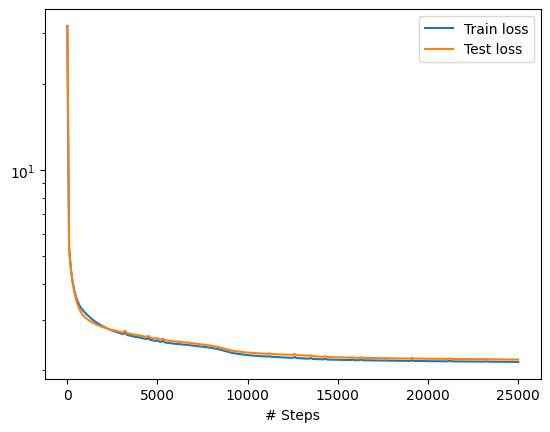

In [21]:
dde.saveplot(
    losshistory, 
    train_state, 
    issave=True, 
    isplot=True,
    output_dir=training_output_dir
)

Predictions shape: (2400, 3)


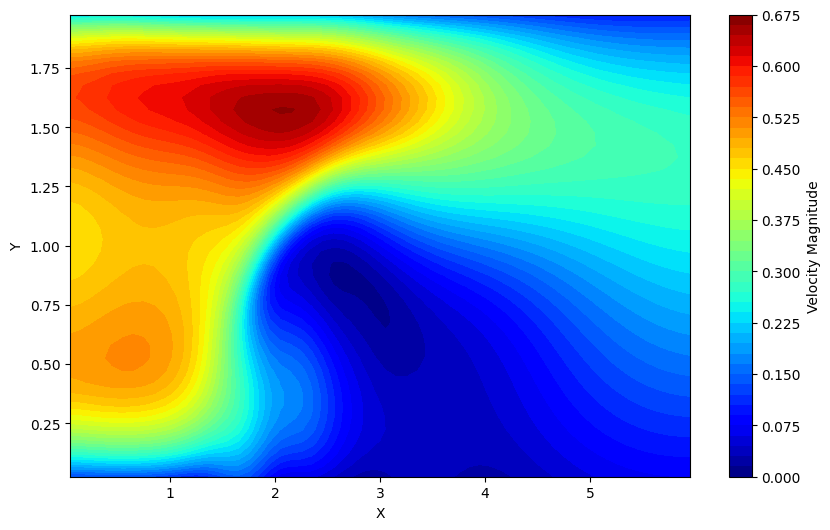

In [43]:
Velocity, Pressure = model_predict(X_grid, Y_grid, time=10.0)

# Plot the predicted velocity magnitude
velocity_magnitude = magnitude(Velocity)
plt.figure(figsize=(10, 6))
plt.contourf(X_grid, Y_grid, velocity_magnitude, levels=50, cmap='jet')
plt.colorbar(label='Velocity Magnitude')
plt.xlabel('X')
plt.ylabel('Y')
plt.savefig(os.path.join(training_output_dir, 'velocity_magnitude.png'))
plt.show()

Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions shape: (2400, 3)
Predictions sh

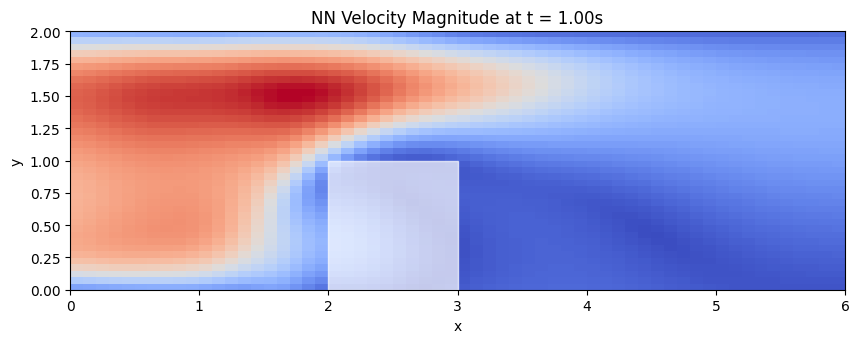

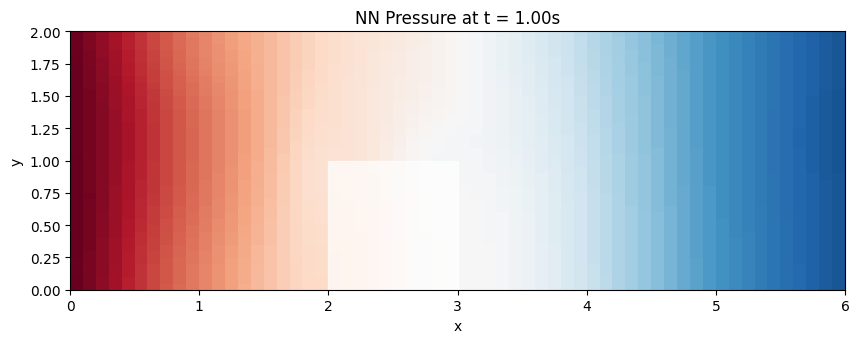

In [ ]:
# Neural network predictions (0 to 10 seconds at 20fps)
time_points = np.linspace(0, 10, 200)
nn_vel_mags = []
nn_pressures = []

for t in time_points:
    vel, press = model_predict(X_grid, Y_grid, time=t)
    nn_vel_mags.append(magnitude(vel).flatten())
    nn_pressures.append(press)

# NN velocity animation
fig_nn_vel, ax_nn_vel = plt.subplots(figsize=(10, 6))
nn_v_min, nn_v_max = np.min(nn_vel_mags), np.max(nn_vel_mags)

def animate_nn_velocity(frame):
    return update_plot(ax_nn_vel, nn_vel_mags[frame], time_points[frame],
                      'NN Velocity Magnitude', vmin=nn_v_min, vmax=nn_v_max)

ani_nn_vel = FuncAnimation(fig_nn_vel, animate_nn_velocity, frames=len(time_points),
                          interval=1000//20, blit=True)
ani_nn_vel.save('nn_velocity_animation.mp4', writer='ffmpeg', fps=20)

# NN pressure animation
fig_nn_press, ax_nn_press = plt.subplots(figsize=(10, 6))
nn_p_min, nn_p_max = np.min(nn_pressures), np.max(nn_pressures)

def animate_nn_pressure(frame):
    return update_plot(ax_nn_press, nn_pressures[frame], time_points[frame],
                      'NN Pressure', vmin=nn_p_min, vmax=nn_p_max, cmap='RdBu_r')

ani_nn_press = FuncAnimation(fig_nn_press, animate_nn_pressure, frames=len(time_points),
                            interval=1000//20, blit=True)
ani_nn_press.save('nn_pressure_animation.mp4', writer='ffmpeg', fps=20)

In [30]:
!jupyter nbconvert --to script 'training-participant.ipynb'

[NbConvertApp] Converting notebook training-participant.ipynb to script
[NbConvertApp] Writing 7122 bytes to training-participant.py
